Kullanılan gesture set:
bend
horizontal_arm_wave
Model:
CNN + Bidirectional LSTM.   Test Accuracy: 0.7058823704719543


In [84]:
import numpy as np
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [85]:
X = np.load("../X_data.npy")
y_gesture = np.load("../y_gesture.npy")

In [86]:
gesture_map = {
    0: "bend",
    1: "forward_kick",
    2: "hand_clap",
    3: "horizontal_arm_wave",
    4: "sit_down",
    5: "squat",
    6: "still",
    7: "two_hands_wave",
    8: "walk"
}

In [87]:
y_gesture_names = np.array([
    gesture_map[label]
    for label in y_gesture
])

In [88]:
selected_gestures = [
    "horizontal_arm_wave",
    "bend"
]

mask = np.isin(
    y_gesture_names,
    selected_gestures
)

X = X[mask]
y_gesture_names = y_gesture_names[mask]

print(X.shape)
print(y_gesture_names.shape)

(246, 100, 64)
(246,)


In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y_gesture_names)

print(le.classes_)

['bend' 'horizontal_arm_wave']


In [90]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y)

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
def normalize_dataset(X):

    X_normalized = []

    for sample in X:

        sample_mean = np.mean(sample)
        sample_std = np.std(sample)

        sample = (
            sample - sample_mean
        ) / (sample_std + 1e-8)

        X_normalized.append(sample)

    return np.array(X_normalized)

X_train = normalize_dataset(X_train)
X_test = normalize_dataset(X_test)

In [93]:
# Gaussian Noise
noise = np.random.normal(
    0,
    0.02,
    X_train.shape
)

X_noise = X_train + noise


# Temporal Shift
def temporal_shift(sample, shift=5):
    return np.roll(sample, shift, axis=0)

X_shifted = np.array([
    temporal_shift(
        x,
        shift=np.random.randint(-5,5)
    )
    for x in X_train
])


# Combine
X_train_final = np.concatenate([
    X_train,
    X_noise,
    X_shifted
], axis=0)

y_train_final = np.concatenate([
    y_train,
    y_train,
    y_train
], axis=0)

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.layers import Bidirectional
model = Sequential([

    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Bidirectional(
    LSTM(64)
),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.4487 - loss: 0.7638 - val_accuracy: 0.3750 - val_loss: 0.7271
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4423 - loss: 0.8019 - val_accuracy: 0.6000 - val_loss: 0.6832
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5577 - loss: 0.7159 - val_accuracy: 0.3750 - val_loss: 0.7101
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6026 - loss: 0.6795 - val_accuracy: 0.5250 - val_loss: 0.6902
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5449 - loss: 0.7060 - val_accuracy: 0.4500 - val_loss: 0.6970
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5513 - loss: 0.6999 - val_accuracy: 0.3750 - val_loss: 0.7278
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4936 - loss: 0.7091 - val_accuracy: 0.6000 - val_loss: 0.6723
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6090 - loss: 0.6825 - val_accuracy: 0.4250 - 

In [96]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6000 - loss: 1.1756
Test Accuracy: 0.6000000238418579


In [97]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=le.classes_
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
                     precision    recall  f1-score   support

               bend       0.61      0.56      0.58        25
horizontal_arm_wave       0.59      0.64      0.62        25

           accuracy                           0.60        50
          macro avg       0.60      0.60      0.60        50
       weighted avg       0.60      0.60      0.60        50



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
GERÇEK: horizontal_arm_wave
TAHMİN: bend
GÜVEN: %90.65


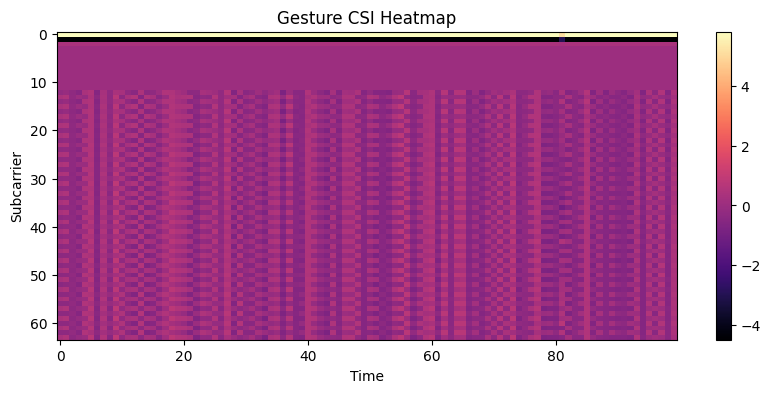

In [98]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(X_test)-1)

sample = X_test[idx]
true_label = np.argmax(y_test[idx])

sample_input = np.expand_dims(sample, axis=0)

prediction = model.predict(sample_input)

pred_class = np.argmax(prediction)

confidence = np.max(prediction)

print("GERÇEK:", le.classes_[true_label])

if confidence < 0.75:

    print("TAHMİN: Belirsiz")

else:

    print("TAHMİN:", le.classes_[pred_class])

print(f"GÜVEN: %{confidence*100:.2f}")

plt.figure(figsize=(10,4))

plt.imshow(
    sample.T,
    aspect='auto',
    cmap='magma'
)

plt.title("Gesture CSI Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar()

plt.show()